# 01 – Análisis Exploratorio del Dataset (EDA)

**Proyecto:** Detección Automática de Fracturas Óseas en Radiografías  
**Materia:** Visión por Computadora II – CEIA/FIUBA  
**Autores:** Lucia T. Capon Paul · César Andrés Orellana · Leandro Britez

---

## Objetivos
- Entender la distribución de clases y particiones del dataset.
- Analizar las características de las imágenes (tamaño, aspecto, brillo).
- Explorar la distribución de bounding boxes (tamaño, densidad, posición).
- Identificar posibles problemas: desbalance, imágenes corruptas, anotaciones atípicas.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from pathlib import Path
import cv2
from PIL import Image
import yaml

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')
print('Librerías importadas correctamente.')

Librerías importadas correctamente.


## 1. Configuración de rutas

In [2]:
DATA_ROOT = Path('../data/bone-fracture-detection-4')
SPLITS = ['train', 'valid', 'test']

# Verificar que el dataset está descargado
assert DATA_ROOT.exists(), (
    f'Dataset no encontrado en {DATA_ROOT}. '
    'Seguí las instrucciones en data/README.md'
)
print(f'Dataset encontrado en: {DATA_ROOT}')

Dataset encontrado en: ../data/bone-fracture-detection-4


In [3]:
DATA_YAML = DATA_ROOT / "data.yaml"

print("¿Existe data.yaml?", DATA_YAML.exists())

¿Existe data.yaml? True


In [4]:
with open(DATA_YAML, "r") as f:
    data_config = yaml.safe_load(f)

data_config

{'train': '../train/images',
 'val': '../valid/images',
 'test': '../test/images',
 'nc': 7,
 'names': ['elbow positive',
  'fingers positive',
  'forearm fracture',
  'humerus',
  'humerus fracture',
  'shoulder fracture',
  'wrist positive'],
 'roboflow': {'workspace': 'veda',
  'project': 'bone-fracture-detection-daoon',
  'version': 4,
  'license': 'CC BY 4.0',
  'url': 'https://universe.roboflow.com/veda/bone-fracture-detection-daoon/dataset/4'}}

## 2. Estadísticas generales por split

In [5]:
print("Cantidad de clases:", data_config["nc"])
print("Nombres de las clases:", data_config["names"])
print("\nMapeo de clases:")

for class_id, class_name in enumerate(data_config["names"]):
    print(f"{class_id} -> {class_name}")

Cantidad de clases: 7
Nombres de las clases: ['elbow positive', 'fingers positive', 'forearm fracture', 'humerus', 'humerus fracture', 'shoulder fracture', 'wrist positive']

Mapeo de clases:
0 -> elbow positive
1 -> fingers positive
2 -> forearm fracture
3 -> humerus
4 -> humerus fracture
5 -> shoulder fracture
6 -> wrist positive


In [6]:
from src.dataset import load_annotations_df

dfs = {}
split_summary = []
for split in SPLITS:
    split_dir = DATA_ROOT / split
    dfs[split] = load_annotations_df(split_dir, data_config)
    total_images = len(list((split_dir / 'images').glob('*.jpg')))
    labeled_images = dfs[split]['image'].nunique()
    split_summary.append({
        'split': split,
        'images_total': total_images,
        'images_with_boxes': labeled_images,
        'images_without_boxes': total_images - labeled_images,
        'annotations': len(dfs[split]),
    })

split_summary_df = pd.DataFrame(split_summary).set_index('split')
display(split_summary_df)

,images_total,images_with_boxes,images_without_boxes,annotations
split,,,,
train,3631,1804,1827,2088
valid,348,173,175,204
test,169,83,86,96


## 3. Distribución de clases

Las imágenes sin archivo de etiquetas vacío representan radiografías sin fractura anotada. Por este motivo, la distribución siguiente se calcula sobre **bounding boxes** y no sobre el total de radiografías.

In [7]:
dfs["train"].head(10)

,image,class_id,class_name,cx,cy,bbox_w,bbox_h
0,distal-humeral-fractures-2-_JPEG.rf.39ba3f5304...,0,elbow positive,0.355859,0.396875,0.452547,0.382974
1,distal-humeral-fractures-2-_JPEG.rf.525ce87678...,0,elbow positive,0.458736,0.380651,0.361454,0.389473
2,distal-humeral-fractures-2-_JPEG.rf.f9442db05e...,0,elbow positive,0.477915,0.375665,0.380450,0.369160
3,elbow-dislocation-with-coronoid-process-fractu...,0,elbow positive,0.379711,0.417125,0.326128,0.614968
4,elbow-dislocation-with-coronoid-process-fractu...,0,elbow positive,0.316769,0.599377,0.370673,0.655045
5,elbow-dislocation-with-coronoid-process-fractu...,0,elbow positive,0.392415,0.401191,0.311819,0.589651
6,fracture-of-the-humeral-capitellum-milch-type-...,0,elbow positive,0.696084,0.743678,0.774201,0.717880
7,fracture-of-the-humeral-capitellum-milch-type-...,0,elbow positive,0.755649,0.830609,0.768056,0.729920
8,fracture-of-the-humeral-capitellum-milch-type-...,0,elbow positive,0.768901,0.813137,0.777149,0.711759
9,image1_0_png.rf.bc222874fa14e205b638e87ddad52b9d,5,shoulder fracture,0.338867,0.261084,0.400570,0.198804


In [8]:
dfs["train"]["class_name"].value_counts()

class_name
fingers positive     531
shoulder fracture    360
elbow positive       339
forearm fracture     316
humerus fracture     311
wrist positive       228
humerus                3
Name: count, dtype: int64

In [9]:
class_distribution = {}

for split in SPLITS:
    
    class_distribution[split] = (
        dfs[split]["class_name"]
        .value_counts()
    )

for split in SPLITS:
    
    print(f"\n{'=' * 40}")
    print(f"{split.upper()}")
    print(f"{'=' * 40}")
    
    print(
        dfs[split]["class_name"]
        .value_counts()
    )


TRAIN
class_name
fingers positive     531
shoulder fracture    360
elbow positive       339
forearm fracture     316
humerus fracture     311
wrist positive       228
humerus                3
Name: count, dtype: int64

VALID
class_name
fingers positive     48
forearm fracture     43
humerus fracture     36
elbow positive       29
wrist positive       28
shoulder fracture    20
Name: count, dtype: int64

TEST
class_name
fingers positive     27
elbow positive       17
shoulder fracture    17
humerus fracture     15
forearm fracture     14
wrist positive        6
Name: count, dtype: int64


In [10]:
class_counts_df = pd.DataFrame(class_distribution).fillna(0)

class_counts_df

,train,valid,test
class_name,,,
elbow positive,339,29.0,17.0
fingers positive,531,48.0,27.0
forearm fracture,316,43.0,14.0
humerus,3,0.0,0.0
humerus fracture,311,36.0,15.0
shoulder fracture,360,20.0,17.0
wrist positive,228,28.0,6.0


In [11]:
class_percentages_df = (
    class_counts_df
    .div(class_counts_df.sum(axis=0), axis=1)
    * 100
)

class_percentages_df

,train,valid,test
class_name,,,
elbow positive,16.235632,14.215686,17.708333
fingers positive,25.431034,23.529412,28.125000
forearm fracture,15.134100,21.078431,14.583333
humerus,0.143678,0.000000,0.000000
humerus fracture,14.894636,17.647059,15.625000
shoulder fracture,17.241379,9.803922,17.708333
wrist positive,10.919540,13.725490,6.250000


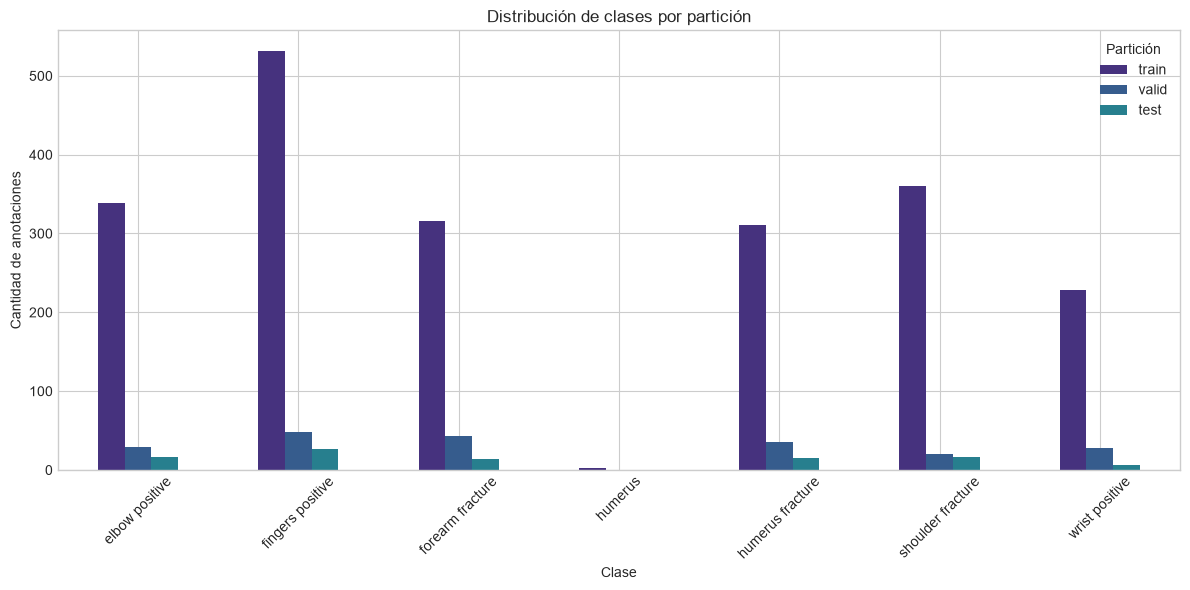

In [12]:
class_counts_df.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Distribución de clases por partición")
plt.xlabel("Clase")
plt.ylabel("Cantidad de anotaciones")
plt.xticks(rotation=45)
plt.legend(title="Partición")

plt.tight_layout()
plt.show()

# Distribución de clases

Una vez verificada la correspondencia entre los identificadores de clase y los nombres definidos en `data.yaml`, se analiza la distribución de las anotaciones correspondientes al conjunto de entrenamiento.

Este análisis permite determinar cuántas *bounding boxes* pertenecen a cada clase y detectar posibles problemas de desbalance en el conjunto de datos.

La distribución obtenida sobre las **2.088 anotaciones del conjunto de entrenamiento** es la siguiente:

| Clase             | Anotaciones | Porcentaje |
| ----------------- | ----------: | ---------: |
| fingers positive  |         531 |    25,43 % |
| shoulder fracture |         360 |    17,24 % |
| elbow positive    |         339 |    16,24 % |
| forearm fracture  |         316 |    15,13 % |
| humerus fracture  |         311 |    14,89 % |
| wrist positive    |         228 |    10,92 % |
| humerus           |           3 |     0,14 % |
| **Total**         |   **2.088** |  **100 %** |

Se observa una distribución heterogénea entre las clases. `fingers positive` es la clase con mayor cantidad de anotaciones, con 531 bounding boxes, mientras que `humerus` presenta solamente 3 anotaciones.

La diferencia entre ambas clases es muy significativa: `fingers positive` representa el 25,43 % de las anotaciones, mientras que `humerus` representa apenas el 0,14 %.

Por lo tanto, el dataset presenta un **fuerte desbalance de clases**, particularmente debido a la escasa representación de la clase `humerus`. Este aspecto deberá ser tenido en cuenta durante las etapas posteriores de entrenamiento y evaluación, ya que una clase con una cantidad extremadamente reducida de ejemplos puede dificultar que el modelo aprenda características representativas y puede generar métricas poco confiables para dicha categoría.

En consecuencia, además de las métricas globales de detección, será necesario analizar el rendimiento **por clase**, especialmente para determinar si el modelo logra detectar correctamente las categorías con menor representación.

Este hallazgo constituye una característica relevante del dataset y será considerado posteriormente al interpretar los resultados de los modelos y evaluar el impacto de las técnicas de *Data Augmentation*.


## 4. Distribución de tamaño de bounding boxes

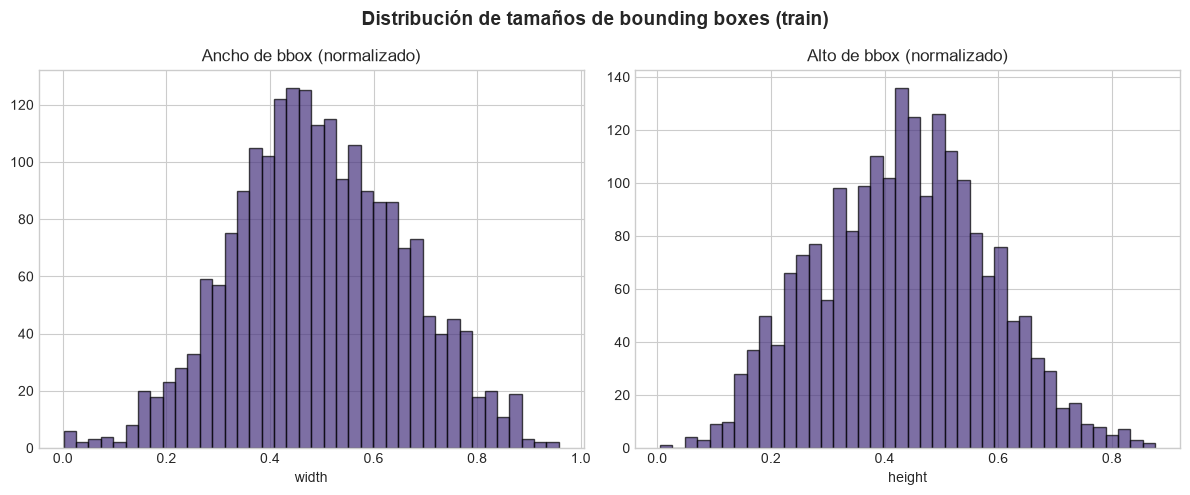

In [13]:
train_df = dfs['train']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].hist(train_df['bbox_w'], bins=40, edgecolor='black', alpha=0.7)
axes[0].set_title('Ancho de bbox (normalizado)')
axes[0].set_xlabel('width')

axes[1].hist(train_df['bbox_h'], bins=40, edgecolor='black', alpha=0.7)
axes[1].set_title('Alto de bbox (normalizado)')
axes[1].set_xlabel('height')

plt.suptitle('Distribución de tamaños de bounding boxes (train)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/01_bbox_size_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Muestras visuales con anotaciones

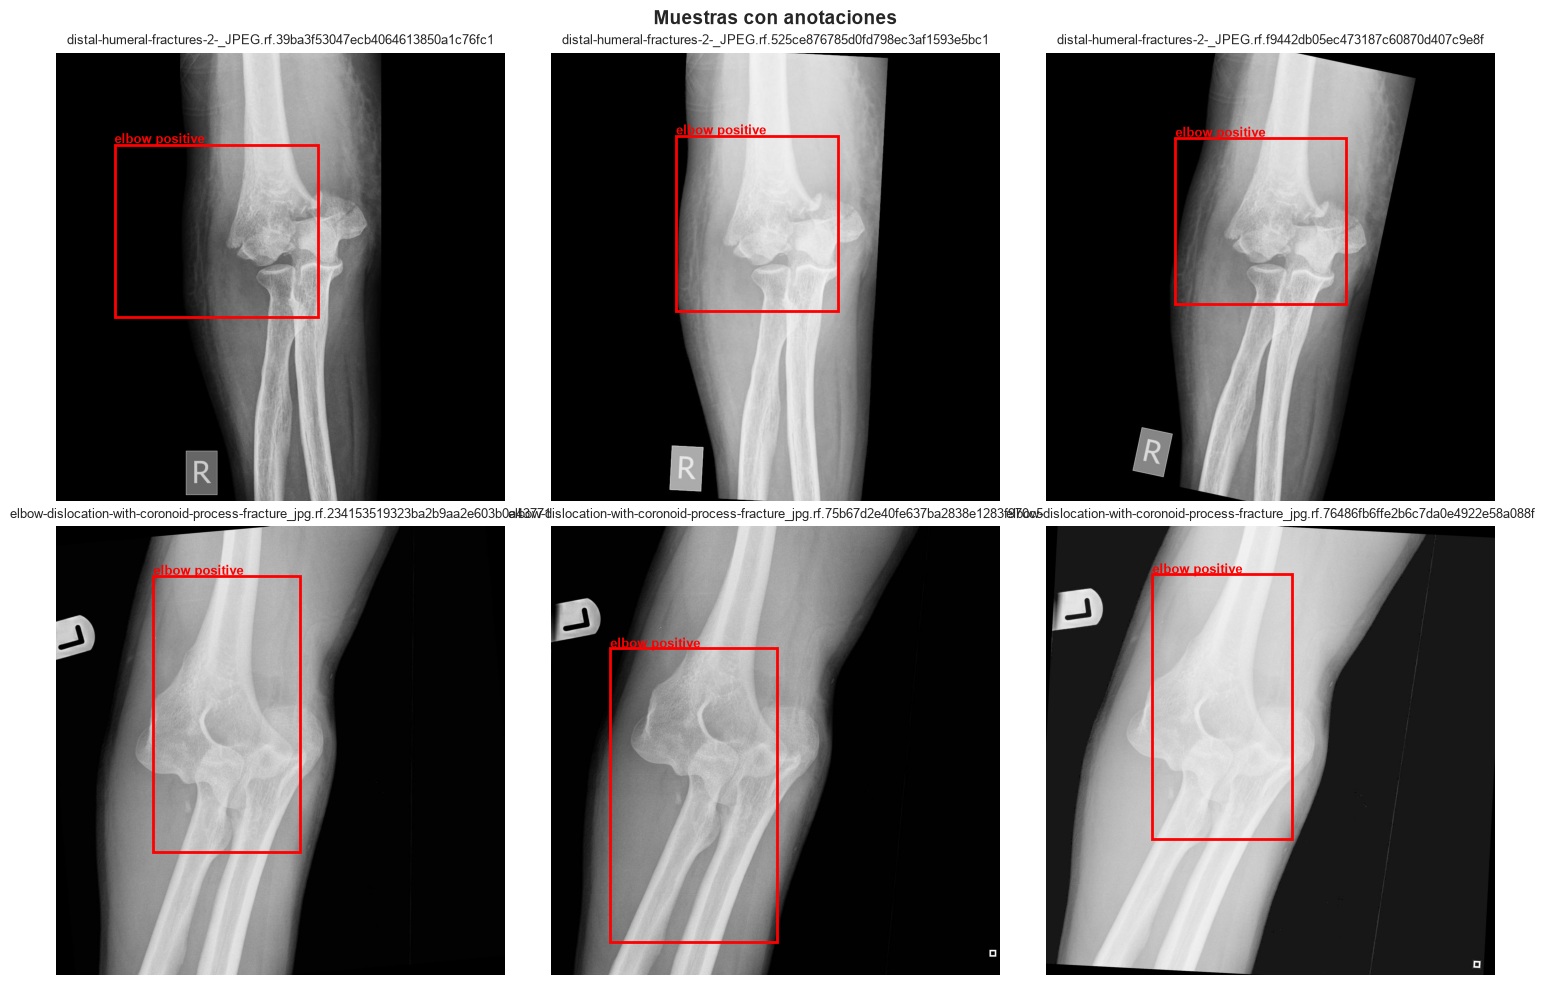

In [14]:
from src.visualize import plot_samples_with_boxes

plot_samples_with_boxes(
    data_dir=DATA_ROOT / 'train',
    annotations_df=dfs['train'],
    n_samples=6,
    save_path='../results/01_sample_annotations.png'
)

## 6. Análisis de propiedades de imagen

In [15]:
from src.dataset import get_image_stats

img_stats = get_image_stats(DATA_ROOT / 'train' / 'images')
display(img_stats.describe())

,width,height,aspect_ratio,mean_brightness,std_brightness
count,3631.000000,3631.000000,3631.000000,3631.000000,3631.000000
mean,412.033324,485.741944,0.883627,54.068331,33.525398
std,115.399559,77.925944,0.349979,38.090143,16.039585
min,111.000000,134.000000,0.217000,0.770000,1.940000
25%,379.000000,492.000000,0.740000,26.610000,22.105000
50%,420.000000,512.000000,0.820000,46.020000,30.750000
75%,512.000000,512.000000,1.041000,70.635000,42.615000
max,2048.000000,2048.000000,3.821000,212.060000,99.740000


## 7. Radiografías positivas y negativas

**Qué se hace:** se compara la cantidad de imágenes con al menos una caja contra las que no tienen cajas. **Por qué:** las imágenes sin cajas son negativos y permiten evaluar falsos positivos. **Resultado esperado:** proporciones similares entre particiones.

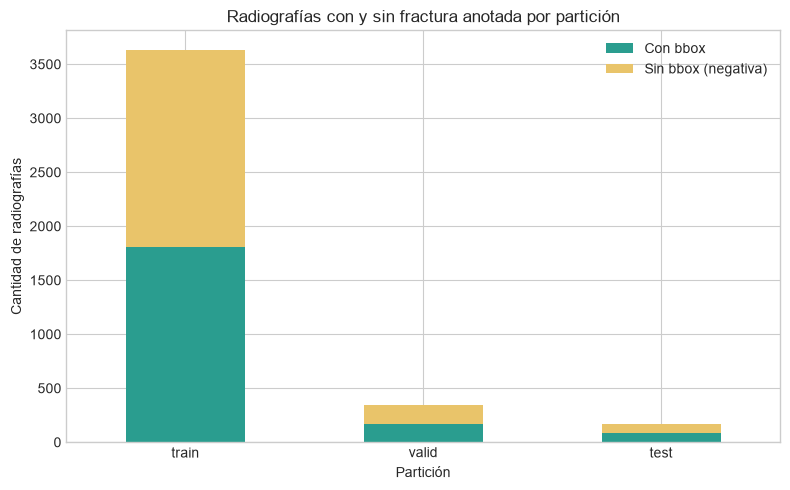

,Con bbox,Sin bbox (negativa)
split,,
train,49.68,50.32
valid,49.71,50.29
test,49.11,50.89


In [16]:
positive_negative = split_summary_df[['images_with_boxes', 'images_without_boxes']].rename(columns={'images_with_boxes': 'Con bbox', 'images_without_boxes': 'Sin bbox (negativa)'})
positive_negative.plot(kind='bar', stacked=True, figsize=(8, 5), color=['#2a9d8f', '#e9c46a'])
plt.title('Radiografías con y sin fractura anotada por partición')
plt.xlabel('Partición'); plt.ylabel('Cantidad de radiografías'); plt.xticks(rotation=0)
plt.tight_layout(); plt.savefig('../results/01_positive_negative_per_split.png', dpi=150, bbox_inches='tight'); plt.show()
display((positive_negative.div(positive_negative.sum(axis=1), axis=0) * 100).round(2))

## 8. Auditoría de anotaciones e imágenes

**Qué se hace:** se verifican clases, geometría de cajas y legibilidad de archivos. **Por qué:** errores de etiquetado o imágenes corruptas invalidan el entrenamiento. **Resultado esperado:** todas las columnas de error deberían ser cero.

In [17]:
from src.dataset import audit_annotations, audit_images
annotation_audit = pd.concat([audit_annotations(dfs[s], data_config['nc']).assign(split=s) for s in SPLITS], ignore_index=True).set_index('split')
image_audit = pd.concat([audit_images(DATA_ROOT / s / 'images').assign(split=s) for s in SPLITS], ignore_index=True).set_index('split')
display(annotation_audit); display(image_audit)

,annotations,invalid_class,invalid_center,invalid_size,out_of_bounds,invalid_any
split,,,,,,
train,2088,0,0,0,449,449
valid,204,0,0,0,33,33
test,96,0,0,0,24,24


,images,unreadable,unreadable_files
split,,,
train,3631,0,-
valid,348,0,-
test,169,0,-


## 9. Duplicados exactos entre particiones

**Qué se hace:** se calcula SHA-256 para cada archivo y se buscan hashes en más de un split. **Por qué:** una imagen repetida entre train y test es fuga de datos. **Alcance:** detecta solo duplicados binarios exactos.

In [18]:
from src.dataset import find_cross_split_duplicates
cross_split_duplicates = find_cross_split_duplicates(DATA_ROOT, SPLITS)
print(f'Duplicados exactos entre particiones: {len(cross_split_duplicates)}')
display(cross_split_duplicates.head(20))

Duplicados exactos entre particiones: 0


,sha256,splits,files


## 10. Posición y área de las bounding boxes

**Qué se hace:** se visualizan centros y áreas normalizadas de las cajas por clase. **Por qué:** permite identificar sesgos espaciales y objetos difíciles por su tamaño. **Resultado esperado:** una figura descriptiva, no una métrica de desempeño.

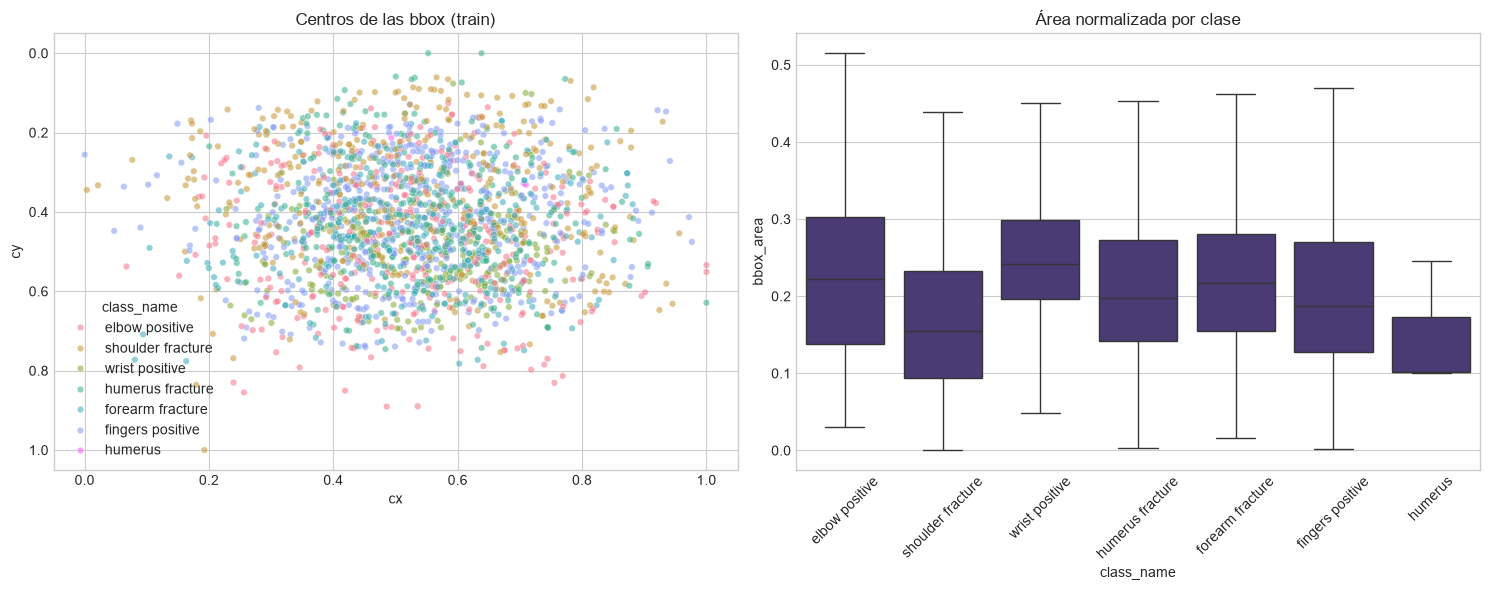

,count,mean,50%,min,max
class_name,,,,,
elbow positive,339.0,0.2307,0.2221,0.0309,0.5737
fingers positive,531.0,0.2064,0.1878,0.0024,0.5411
forearm fracture,316.0,0.2228,0.2175,0.0162,0.5357
humerus,3.0,0.1492,0.1016,0.1005,0.2454
humerus fracture,311.0,0.2147,0.1977,0.0033,0.6221
shoulder fracture,360.0,0.1814,0.1549,0.0005,0.5636
wrist positive,228.0,0.2527,0.2422,0.0417,0.5567


In [19]:
train_boxes = dfs['train'].copy(); train_boxes['bbox_area'] = train_boxes['bbox_w'] * train_boxes['bbox_h']
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.scatterplot(data=train_boxes, x='cx', y='cy', hue='class_name', alpha=.55, s=22, ax=axes[0]); axes[0].invert_yaxis(); axes[0].set_title('Centros de las bbox (train)')
sns.boxplot(data=train_boxes, x='class_name', y='bbox_area', ax=axes[1], showfliers=False); axes[1].set_title('Área normalizada por clase'); axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.savefig('../results/01_bbox_position_area_by_class.png', dpi=150, bbox_inches='tight'); plt.show()
display(train_boxes.groupby('class_name')['bbox_area'].describe()[['count', 'mean', '50%', 'min', 'max']].round(4))

---
## Conclusiones del EDA

A partir del análisis realizado, se obtuvieron las siguientes observaciones:

1. El dataset está formado por 4.148 radiografías: 3.631 para entrenamiento, 348 para validación y 169 para prueba. En las tres particiones, aproximadamente la mitad de las imágenes tiene al menos una caja anotada y la otra mitad no tiene cajas. Para este trabajo, estas últimas se consideran ejemplos negativos, ya que le permiten al modelo aprender cuándo no debe detectar una fractura.

2. Se observó un desbalance entre las clases. En entrenamiento, `fingers positive` es la clase con más anotaciones (531), mientras que `humerus` solo tiene 3. Además, `humerus` no aparece en validación ni en test. Por este motivo, cualquier resultado de esa clase debe interpretarse con cuidado y no sería posible evaluarla correctamente en el conjunto de prueba.

3. Las cajas delimitadoras tienen tamaños variados. La mediana del área normalizada es 0,201; por lo tanto, muchas anotaciones ocupan una parte importante de la radiografía. Sin embargo, en clases como `fingers positive` y `shoulder fracture` también aparecen cajas muy pequeñas. Esto puede hacer que algunos casos sean más difíciles de detectar.

4. Las imágenes tienen resoluciones, relaciones de aspecto y niveles de brillo bastante diferentes. Por ejemplo, el ancho varía entre 111 y 2.048 píxeles y el brillo medio entre 0,77 y 212,06. Por esta razón, usar un tamaño de entrada fijo y aplicar aumentos moderados de brillo, contraste, escala y rotación parece una decisión razonable para el entrenamiento.

5. No se encontraron imágenes ilegibles ni duplicados exactos entre las particiones de entrenamiento, validación y prueba. Esto es positivo porque, al menos para duplicados idénticos, no se detectó fuga de datos entre los conjuntos.

6. La auditoría encontró cajas que superan alguno de los límites de la imagen: 449 en entrenamiento, 33 en validación y 24 en test. Esto no significa necesariamente que las anotaciones estén mal, ya que algunas pueden corresponder a regiones recortadas en el borde de la radiografía. De todos modos, conviene revisar una muestra de estos casos antes de entrenar para confirmar que las etiquetas sean coherentes.

En conclusión, el dataset permite realizar el experimento propuesto, pero tiene dos limitaciones importantes: el desbalance de clases y la falta de ejemplos de `humerus` en test. Durante la evaluación será importante analizar las métricas por clase, además de las métricas globales, y revisar especialmente los falsos negativos. El sistema se plantea como una herramienta de apoyo para la detección de fracturas y no como un reemplazo del diagnóstico profesional.